# Data Extraction and Preparation

## Overview

This phase focuses on extracting and organizing the PTB-XL ECG dataset components for our analysis. The dataset was previously downloaded to the `../data` directory.

## Dataset Components

We'll work with two primary components:

1. **High-Resolution ECG Waveforms**
   - Located in `../data/records500/` directory
   - Sampled at 500Hz for precise signal analysis
   - Stored in standard ECG file formats

2. **Metadata and Annotations**
   - Primary index file: `../data/ptbxl_database.csv`
   - Contains patient demographics, diagnostic information, and recording details
   - Provides the mapping between ECG recordings and patient identifiers

## Data Organization Strategy

The metadata serves as our relational bridge between raw signal data and patient information. For our biometric identification task, we'll use:

- ECG waveforms as our feature inputs (X)
- Patient IDs as our categorical target labels (y)

In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

# Configuration
SAMPLING_RATE = 500
QRS_WINDOW = 200 # 400ms total window
SAMPLES_PER_PATIENT = 10 # Number of beats to extract per person
LEADS = [0, 1] # Lead I and Lead II

# Loaded data paths
data_dir = "..\data"
root_name = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
extracted_folder = os.path.join(data_dir, root_name)

## ECG Signal Processing

### Bandpass Filtering
Implements a 4th-order zero-phase Butterworth filter to:
- Remove low-frequency baseline drift (< 0.5 Hz)
- Eliminate high-frequency noise (> 40 Hz)
- Isolate the QRS complex for accurate cardiac analysis
- Preserve critical morphological features of the waveform

### Signal Standardization
Applies Z-score normalization to:
- Transform signals to zero mean and unit standard deviation
- Focus analysis on waveform morphology (curves and slopes)
- Create invariance to amplitude variations caused by:
  - Different sensor gain settings
  - Variable skin-electrode impedance
  - Patient-specific physiological differences
- Ensure consistent performance across diverse recording conditions

In [2]:
from scipy.signal import butter, filtfilt

def apply_filter(signal, lowcut=0.5, highcut=40.0, fs=500):
    """
    Applies a 4th-order zero-phase Butterworth bandpass filter.
    Isolates the QRS complex by removing DC drift and high-frequency jitter.
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, signal)

def z_score_normalize(segment):
    """
    Standardizes signal amplitude to a mean of 0 and standard deviation of 1.
    Ensures the CNN is invariant to sensor gain and skin-electrode impedance.
    """
    return (segment - np.mean(segment)) / (np.std(segment) + 1e-8)

## QRS Complex Extraction

### Precision Heartbeat Isolation

The extraction process carefully identifies and isolates individual heartbeats from multi-lead ECG recordings to:
- Eliminate inter-beat variability
- Focus on stable biometric features
- Reduce noise artifacts

### Advanced Signal Processing Pipeline

Each multi-lead waveform undergoes a systematic processing sequence:
1. **Beat Detection** - Precise localization of QRS complexes across all leads
2. **Segment Windowing** - Extraction of fixed-length segments centered on R-peaks
3. **Normalization** - Standardization of amplitude and temporal characteristics

This preprocessing approach significantly improves model robustness and identification accuracy.

In [3]:
import wfdb
from wfdb import processing
from tqdm import tqdm

# QRS extraction function
def prepare_biometric_data(df, base_path):
    """
    Orchestrates the conversion of raw PTB-XL files into a synchronized 4D tensor.
    
    Workflow:
    1. Parse raw signal leads (I and II).
    2. Apply Butterworth bandpass filtering to mitigate noise.
    3. Detect R-peaks via the GQRS algorithm.
    4. Window exactly SAMPLES_PER_PATIENT beats per subject.
    5. Standardize amplitudes via Z-score normalization.
    
    Returns:
        X (np.array): (N_Patients, SAMPLES_PER_PATIENT, 2, 200)
        Y (np.array): (N_Patients,) - raw patient IDs
    """
    X = []
    Y = []
    
    for index, row in tqdm(df.iterrows(), total=df.shape[0]):
        try:
            # Load specific leads (I and II)
            signal, meta = wfdb.rdsamp(os.path.join(base_path, row['filename_hr']), channels=LEADS)
            
            # 1. Filter the signal
            filtered = np.array([apply_filter(signal[:, i]) for i in range(len(LEADS))])
            
            # 2. Peak Detection (using simple max-finding or wfdb's gqrs)
            # For speed, we use a simple peak detection here
            # In a production env, use neurokit2.ecg_peaks
            peaks = wfdb.processing.gqrs_detect(sig=filtered[0], fs=SAMPLING_RATE)
            
            # 3. Extract fixed number of segments
            patient_beats = []
            for p in peaks:
                if p > 100 and p < (len(filtered[0]) - 100):
                    # Extract 2 leads
                    beat = filtered[:, p-100 : p+100]
                    # Normalize each lead separately
                    beat = np.array([z_score_normalize(beat[i]) for i in range(len(LEADS))])
                    patient_beats.append(beat)
                
                if len(patient_beats) == SAMPLES_PER_PATIENT:
                    break
            
            if len(patient_beats) == SAMPLES_PER_PATIENT:
                X.append(patient_beats)
                Y.append(index) # Use ecg_id as label
                
        except Exception as e:
            print(e)
            continue
            
    return np.array(X), np.array(Y)

## Caching and Preprocessing Pipeline

### Preprocessing Workflow

When cached data is unavailable, the system executes a comprehensive preprocessing sequence:

#### 1. Quality Control
- Filters the `ptbxl_database.csv` dataset
- Retains only records with `validated_by_human == True`

#### 2. Advanced Feature Engineering
- Transforms raw 10-second ECG recordings
- Structures data into optimized `(Beats, Leads, Samples)` format
- Extracts clinically relevant cardiac features

#### 3. Efficient Storage
- Compresses processed signals (`X`) and labels (`Y`) into a single `biometric_data.npz` archive
- Serializes the `LabelEncoder` object to `patient_encoder.pkl`
- Preserves class mapping for consistent patient identification

In [4]:
import pickle

file_path = Path('../data/biometric_data.npz')
encoder_path = Path('../data/patient_encoder.pkl')

if file_path.exists() and encoder_path.exists():
    data = np.load(file_path)
    X = data['x']
    Y_encoded = data['y']
    with open(encoder_path, 'rb') as f:
        encoder = pickle.load(f)
else:
    # Load metadata
    df = pd.read_csv(os.path.join(extracted_folder, 'ptbxl_database.csv'), index_col='ecg_id')
    
    # For Biometrics, we only want records where data quality is high
    df = df[df.validated_by_human == True]
    
    # Process the data
    X, Y = prepare_biometric_data(df, extracted_folder)
    
    # Encode Labels (Patient IDs) to 0...N
    encoder = LabelEncoder()
    Y_encoded = encoder.fit_transform(Y)

    # 1. Ensure X and Y are numpy arrays
    X_final = np.array(X)
    Y_final = np.array(Y_encoded)
    
    # 2. Save X and Y using compressed format (.npz)
    # This significantly reduces file size for ECG data
    np.savez_compressed('../data/biometric_data.npz', x=X_final, y=Y_final)
    
    # 3. CRITICAL: Save the LabelEncoder
    # Without this, you won't know which index belongs to which patient ID later
    with open('../data/patient_encoder.pkl', 'wb') as f:
        pickle.dump(encoder, f)
    
print("Data loaded successfully.")

Data loaded successfully.


## Dimensional Validation

The system performs comprehensive validation across all tensor dimensions to ensure data consistency and model compatibility:

- **Patient Dimension (N=10472)**: Verifies all filtered patient records
- **Beat Dimension (10)**: Confirms extraction of exactly 10 QRS complexes per patient
- **Lead Dimension (2)**: Confirms presence of both Lead I and Lead II signals
- **Sample Dimension (200)**: Verifies uniform time-series window length across all segments

In [5]:
if len(X) > 0:
    # 2. Check the shape of the NumPy array
    # If successful, this should be (NumPatients, 10, 2, 200)
    print(f"Shape of X array: {X.shape}")
    print(f"Shape of Y array: {Y_encoded.shape}")
    
    # 3. Check unique identities (classes)
    num_unique_patients = len(np.unique(Y_encoded))
    print(f"Number of unique patient identities: {num_unique_patients}")
    
    # 4. Inspect a single sample for internal verification
    # X[0] is the first patient, X[0][0] is their first beat
    print(f"Shape of one patient's data: {X[0].shape}")
    print(f"Shape of a single beat: {X[0][0].shape}")
else:
    print("CRITICAL: X contains no data. Check your file paths or peak detection logic.")

Shape of X array: (10472, 10, 2, 200)
Shape of Y array: (10472,)
Number of unique patient identities: 10472
Shape of one patient's data: (10, 2, 200)
Shape of a single beat: (2, 200)


## Visual Data Audit

Take some random samples and visualize them to confirm that:

- QRS complexes are centered and normalized: preservation of relative wave amplitudes (P, QRS, T)
- There is no normalization artifacts or distortions
- Multiple samples from the same patient are consistent

In [6]:
import matplotlib.pyplot as plt
import random

def visualize_biometric_samples(X, Y_encoded, encoder, num_patients=3, beats_per_patient=2):
    """
    Renders a grid of ECG waveforms to verify QRS extraction quality.
    
    Args:
        X (np.array): Processed tensor of shape (Patients, 10, 2, 200).
        Y_encoded (np.array): Integer labels for each patient.
        encoder (LabelEncoder): The fitted encoder used to retrieve original Patient IDs.
        num_patients (int): Vertical rows in the grid (different identities).
        beats_per_patient (int): Horizontal columns (consistency check for one identity).
    """
    # Pick random patients
    patient_indices = random.sample(range(len(X)), num_patients)
    
    fig, axes = plt.subplots(num_patients, beats_per_patient, 
                             figsize=(15, 4 * num_patients), 
                             sharex=True, sharey=True)
    
    # Handle single patient/beat case for indexing
    if num_patients == 1: axes = [axes]
    if beats_per_patient == 1: axes = [[a] for a in axes]

    for i, p_idx in enumerate(patient_indices):
        # Get the original patient ID from the encoder if using Y_encoded, 
        # otherwise use Y directly
        encoded_val = Y_encoded[p_idx]
        original_id = encoder.inverse_transform([encoded_val])[0]
        
        # Pick random beats for this patient
        beat_indices = random.sample(range(X.shape[1]), beats_per_patient)
        
        for j, b_idx in enumerate(beat_indices):
            # Extract Lead I and Lead II
            # Shape: (2, 200)
            sample_leads = X[p_idx, b_idx]
            
            ax = axes[i][j]
            ax.plot(sample_leads[0], label='Lead I', color='#1f77b4', alpha=0.8)
            ax.plot(sample_leads[1], label='Lead II', color='#ff7f0e', alpha=0.8)
            
            ax.set_title(f"Patient ID: {original_id} | Beat {b_idx}")
            ax.grid(True, linestyle='--', alpha=0.6)
            if i == num_patients - 1: ax.set_xlabel("Time (Samples)")
            if j == 0: ax.set_ylabel("Normalized Amp")
            if i == 0 and j == 0: ax.legend()

    plt.tight_layout()
    plt.show()

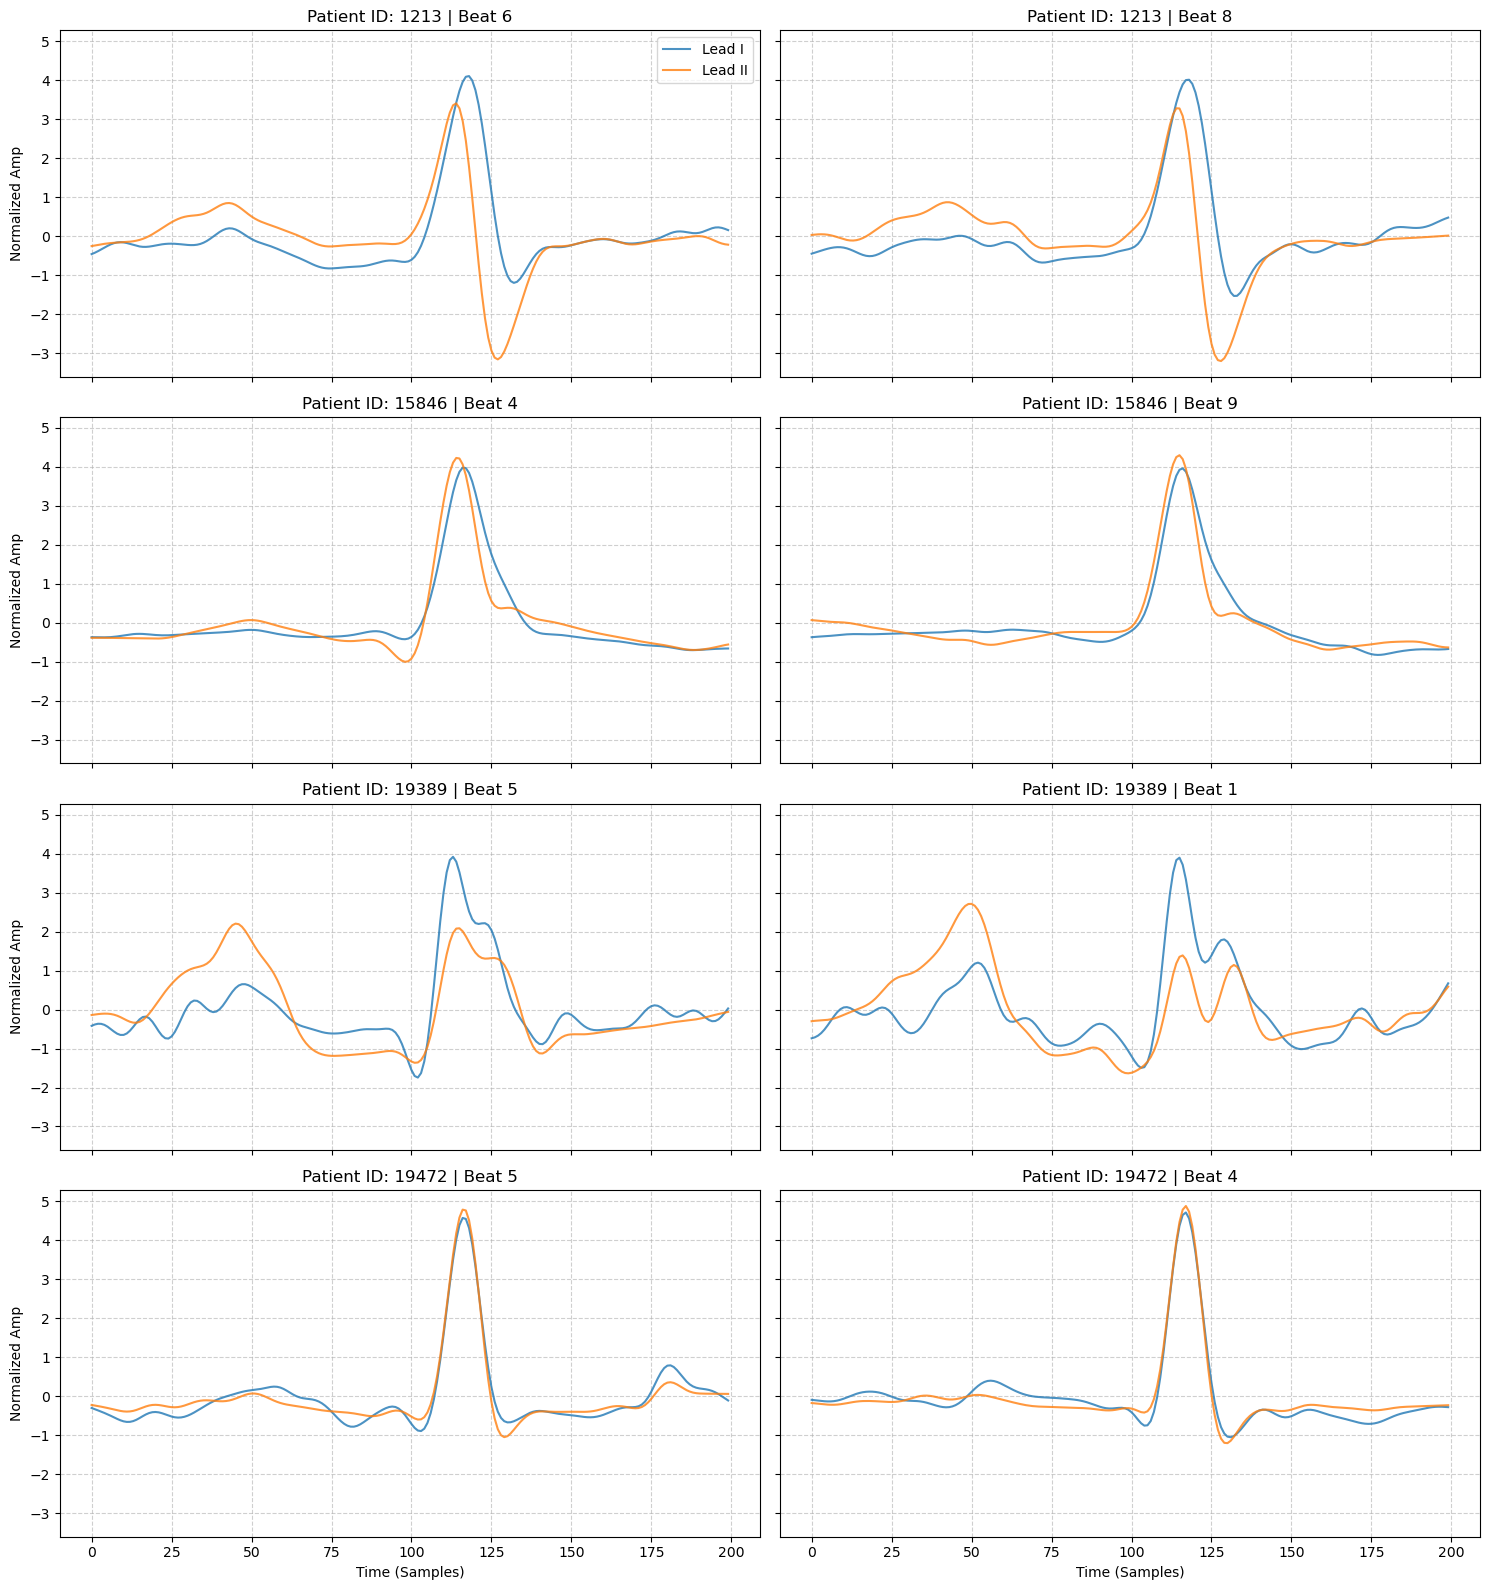

In [7]:
# Run the visualization
visualize_biometric_samples(X, Y_encoded, encoder, num_patients=4, beats_per_patient=2)